In [9]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer, TfidfVectorizer
from sklearn.decomposition import NMF

# Output folder
output_dir = Path("outputs_text_analysis")
output_dir.mkdir(exist_ok=True)

# Text column
TEXT_COL = "text"

# Final stopwords for HD-level cleaning
# These remove common English words, Twitter noise, Bitcoin repetition, and spam-like phrases.
custom_stopwords_hd = {
    # Twitter / platform noise
    "rt", "amp", "https", "http", "www", "com",
    "username", "user", "users", "tweet", "tweets", "twitter",
    "follow", "followers", "link", "join", "tips",
    
    # Domain words that are too obvious because all data is about Bitcoin/crypto
    "btc", "bitcoin", "crypto", "cryptocurrency",
    
    # Generic low-value words
    "just", "like", "time", "people", "don", "good", "going", "think",
    "know", "make", "need", "new", "really", "want", "way", "day",
    "today", "thing", "things", "let", "look", "still", "much",
    "many", "say", "said", "year", "years", "week", "weeks",
    "great", "right", "best", "big", "soon", "use", "better",
    
    # Spam/promotional/noisy terms found in previous outputs
    "seasonaltokens", "cryptomining", "cyclicalinvesting", "cyclicallnvesting",
    "betfurysuccess", "cashback", "rank", "play", "higher", "staking"
}

stopwords_hd = set(ENGLISH_STOP_WORDS).union(custom_stopwords_hd)

def clean_text_hd(text):
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)
    
    # Remove mentions
    text = re.sub(r"@\w+", " ", text)
    
    # Remove hashtag symbol but keep hashtag word
    text = re.sub(r"#", " ", text)
    
    # Keep letters only
    text = re.sub(r"[^a-z\s]", " ", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    # Token filtering
    tokens = [
        word for word in text.split()
        if word not in stopwords_hd and len(word) > 2
    ]
    
    return " ".join(tokens)

# Apply final cleaning
df["clean_text_hd"] = df[TEXT_COL].apply(clean_text_hd)

# Remove empty rows
df_clean_hd = df[df["clean_text_hd"].str.len() > 2].copy()

print("Original rows:", len(df))
print("Rows after HD cleaning:", len(df_clean_hd))

df_clean_hd[["text", "clean_text_hd"]].head(10)

Original rows: 632179
Rows after HD cleaning: 627413


,text,clean_text_hd
16,@MexcResearch @MEXC_Fans @MEXC_Updates #BTC - ...,amazing impressed project hopefully event comm...
24,@iamDonaldYusuf @yuzomausman @aproko_doctor No...,fud sub wan risk buy prices imo
25,I personally ignore weekend moves and chill wi...,personally ignore weekend moves chill family
31,Move Digital Energy Through Cyber Space. #Bitc...,digital energy cyber space
51,"1/2 End of shitcoin season, lasted even longer...",end shitcoin season lasted longer expected fro...
59,More traditional market content going on the T...,traditional market content tube content youtub...
61,Less than 10hours to save #Bitcoin weekly cand...,hours save weekly candle
87,@JasonPLowery Real Question?\n\nWouldn’t this ...,real question wouldn mean nations warfare long...
89,@JoshuaBarbin1 @danheld How do you get more de...,decentralized network tens thousands nodes cou...
110,#11MINUTES #BTC #CRYPTO\nThis project is a pro...,minutes project profitable project investors i...


,word,frequency
5,buy,48810
10,eth,41161
19,market,38591
20,money,37050
21,price,32977
22,project,30532
11,ethereum,23295
29,world,20846
18,long,18557
13,future,17046


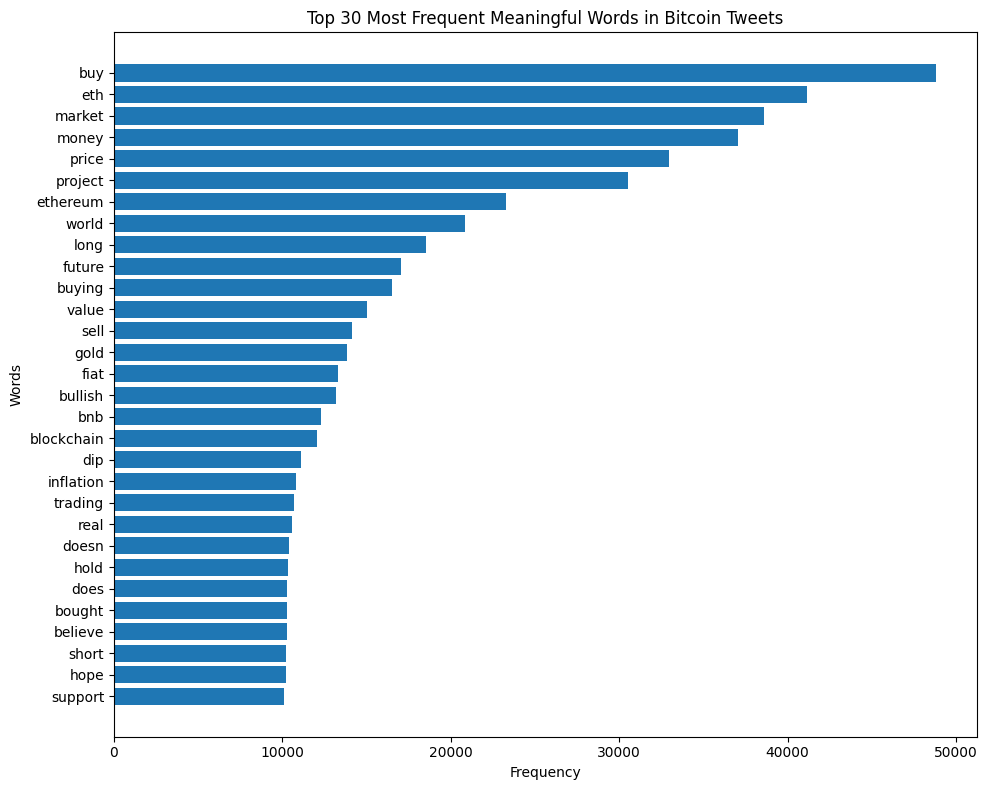

In [10]:
# Final word frequency analysis

word_vectorizer = CountVectorizer(
    stop_words=list(stopwords_hd),
    max_features=30
)

word_matrix = word_vectorizer.fit_transform(df_clean_hd["clean_text_hd"])

word_counts = word_matrix.sum(axis=0).A1
words = word_vectorizer.get_feature_names_out()

top_words_hd = pd.DataFrame({
    "word": words,
    "frequency": word_counts
}).sort_values(by="frequency", ascending=False)

display(top_words_hd)

# Save table
top_words_hd.to_csv(output_dir / "top_30_words_hd.csv", index=False)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(top_words_hd["word"][::-1], top_words_hd["frequency"][::-1])
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title("Top 30 Most Frequent Meaningful Words in Bitcoin Tweets")
plt.tight_layout()
plt.savefig(output_dir / "top_30_words_hd.png", dpi=300, bbox_inches="tight")
plt.show()

,bigram,frequency
0,bear market,5601
16,long term,5432
2,bull run,2995
4,buy dip,2789
29,store value,2731
17,market cap,2705
26,short term,2636
1,bull market,2458
14,legal tender,1700
10,current price,1673


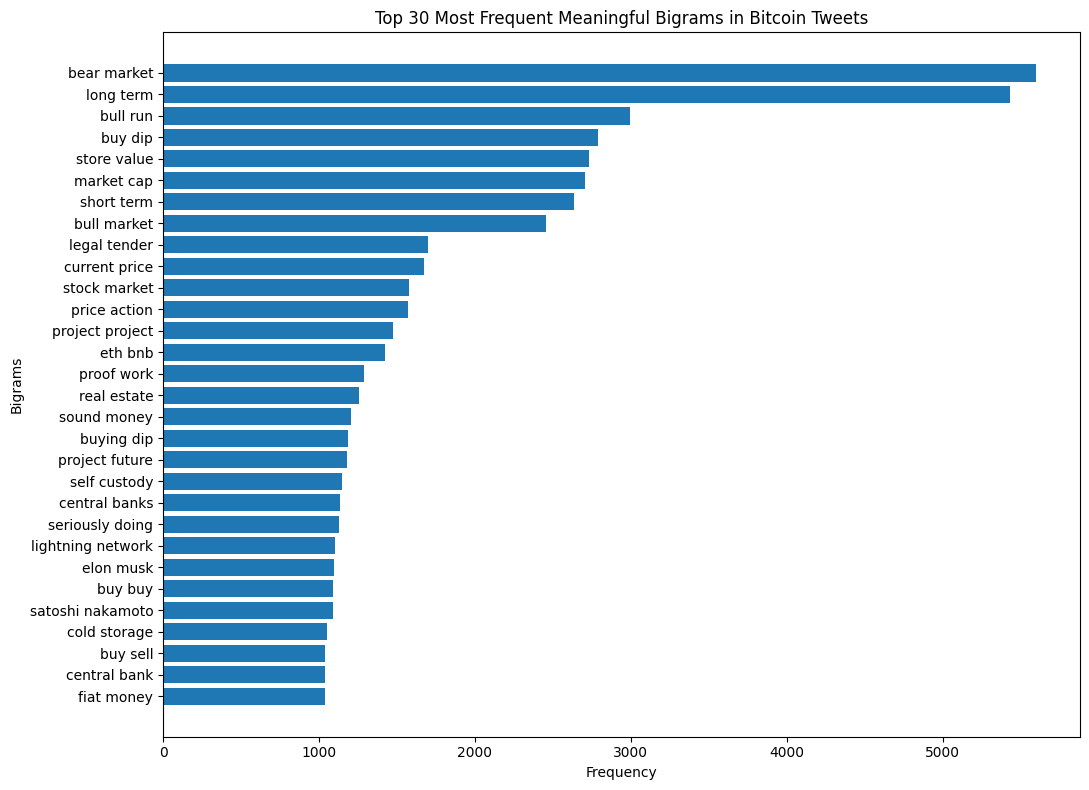

In [11]:
# Final bigram frequency analysis

bigram_vectorizer = CountVectorizer(
    stop_words=list(stopwords_hd),
    ngram_range=(2, 2),
    max_features=30
)

bigram_matrix = bigram_vectorizer.fit_transform(df_clean_hd["clean_text_hd"])

bigram_counts = bigram_matrix.sum(axis=0).A1
bigrams = bigram_vectorizer.get_feature_names_out()

top_bigrams_hd = pd.DataFrame({
    "bigram": bigrams,
    "frequency": bigram_counts
}).sort_values(by="frequency", ascending=False)

display(top_bigrams_hd)

# Save table
top_bigrams_hd.to_csv(output_dir / "top_30_bigrams_hd.csv", index=False)

# Plot
plt.figure(figsize=(11, 8))
plt.barh(top_bigrams_hd["bigram"][::-1], top_bigrams_hd["frequency"][::-1])
plt.xlabel("Frequency")
plt.ylabel("Bigrams")
plt.title("Top 30 Most Frequent Meaningful Bigrams in Bitcoin Tweets")
plt.tight_layout()
plt.savefig(output_dir / "top_30_bigrams_hd.png", dpi=300, bbox_inches="tight")
plt.show()
